# Medical Insurance Cost Prediction
### A Linear Regression Project — Phases 1 to 6

This notebook follows the complete ML workflow: problem understanding, dataset exploration,
cleaning & preprocessing, exploratory data analysis, model training, and evaluation.


## Phase 1 — Understand the Problem

**Problem statement:** Health insurers price policies based on the expected medical cost of a
customer. Estimating this cost accurately up front — instead of a flat rate for everyone — lets an
insurer set fair, risk-adjusted premiums: higher for customers likely to incur higher claims (e.g.
smokers, older customers, higher BMI) and lower for lower-risk customers. This is a **regression**
problem because the thing we're predicting (`charges`) is a continuous number, not a category.

**Target variable:** `charges` — the individual medical insurance cost billed by the insurer (USD).

**Input features:**
- `age` — age of the primary beneficiary
- `sex` — female / male
- `bmi` — body mass index
- `children` — number of dependents covered by the insurance
- `smoker` — smoking status (yes/no)
- `region` — residential area in the US (northeast, northwest, southeast, southwest)

**Real-world use case:** An insurance company can plug a new applicant's profile into this model to
get an estimated annual cost *before* underwriting, helping set premiums, flag high-risk applicants
for further review, and simulate how a factor like quitting smoking would change a customer's
expected cost.


## Phase 2 — Dataset Collection & Exploration

Dataset: **Medical Cost Personal Dataset** (the well-known Kaggle "insurance.csv" dataset).


In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("insurance.csv")
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [2]:
print("Shape (rows, columns):", df.shape)


Shape (rows, columns): (1338, 7)


In [3]:
print("Column names:")
list(df.columns)


Column names:


['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [5]:
df.describe(include='all')


,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


## Phase 3 — Data Cleaning & Preprocessing

We check for missing values, duplicate rows, and incorrect data types, then encode the categorical
columns (`sex`, `smoker`, `region`) into numeric form so a Linear Regression model can use them.


In [6]:
# Missing value analysis
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
# Duplicate analysis
dupes = df.duplicated().sum()
print(f"Number of duplicate rows: {dupes}")


Number of duplicate rows: 1


In [8]:
# Drop duplicates if any, and confirm data types are sensible
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Shape before:", df.shape, " Shape after dropping duplicates:", df_clean.shape)
df_clean.dtypes


Shape before: (1338, 7)  Shape after dropping duplicates: (1337, 7)


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [9]:
# BEFORE preprocessing: categorical columns are still text
df_clean[['sex', 'smoker', 'region']].head()


,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [10]:
# Encode categorical variables
# sex: female=0, male=1   |   smoker: no=0, yes=1   |   region: one-hot encoded
df_encoded = df_clean.copy()
df_encoded['sex'] = df_encoded['sex'].map({'female': 0, 'male': 1})
df_encoded['smoker'] = df_encoded['smoker'].map({'no': 0, 'yes': 1})
df_encoded = pd.get_dummies(df_encoded, columns=['region'], drop_first=True)

# AFTER preprocessing
df_encoded.head()


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


In [11]:
print("Final dataset shape prepared for ML:", df_encoded.shape)
df_encoded.dtypes


Final dataset shape prepared for ML: (1337, 9)


age                   int64
sex                   int64
bmi                 float64
children              int64
smoker                int64
charges             float64
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object

## Phase 4 — Exploratory Data Analysis

We look at how `charges` relates to `age`, `bmi`, and `smoker` status, and check correlations
between all numeric variables.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


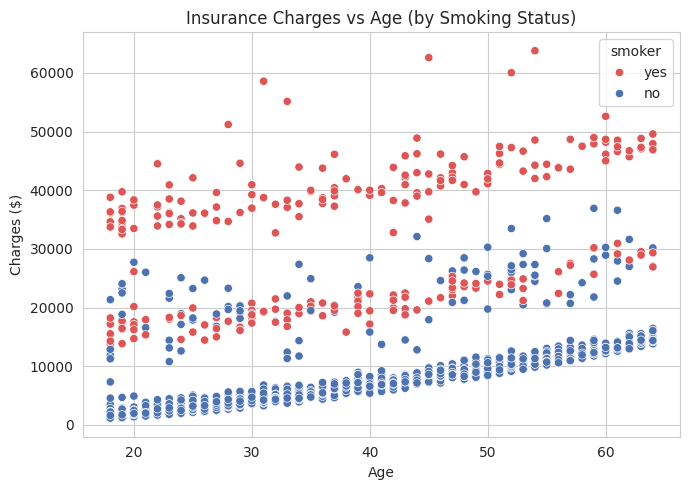

In [13]:
# 1. Charges vs Age, colored by smoking status
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_clean, x='age', y='charges', hue='smoker', palette={'no':'#4C72B0','yes':'#DD5555'})
plt.title("Insurance Charges vs Age (by Smoking Status)")
plt.xlabel("Age")
plt.ylabel("Charges ($)")
plt.tight_layout()
plt.show()


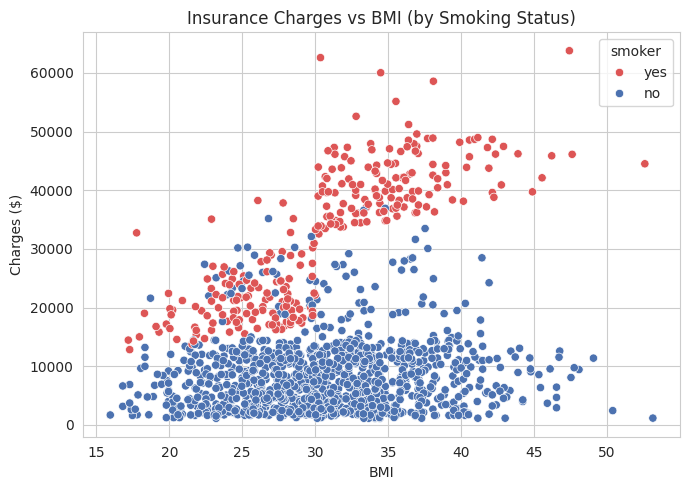

In [14]:
# 2. Charges vs BMI, colored by smoking status
plt.figure(figsize=(7,5))
sns.scatterplot(data=df_clean, x='bmi', y='charges', hue='smoker', palette={'no':'#4C72B0','yes':'#DD5555'})
plt.title("Insurance Charges vs BMI (by Smoking Status)")
plt.xlabel("BMI")
plt.ylabel("Charges ($)")
plt.tight_layout()
plt.show()


/tmp/ipykernel_126/2676541961.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='smoker', y='charges', palette={'no':'#4C72B0','yes':'#DD5555'})


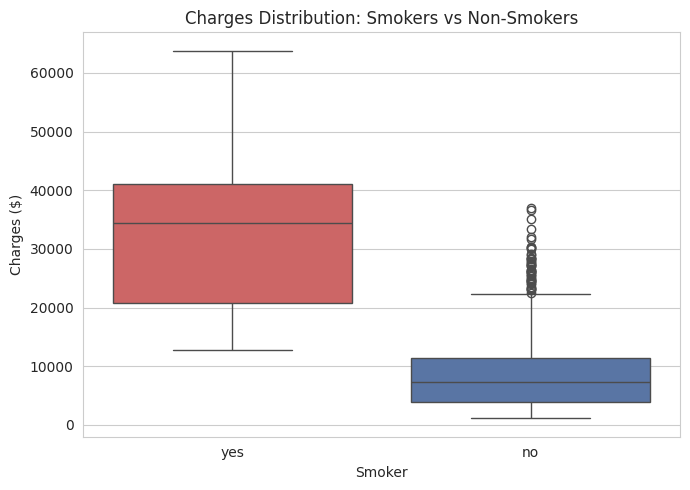

In [15]:
# 3. Charges distribution: smokers vs non-smokers
plt.figure(figsize=(7,5))
sns.boxplot(data=df_clean, x='smoker', y='charges', palette={'no':'#4C72B0','yes':'#DD5555'})
plt.title("Charges Distribution: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Charges ($)")
plt.tight_layout()
plt.show()


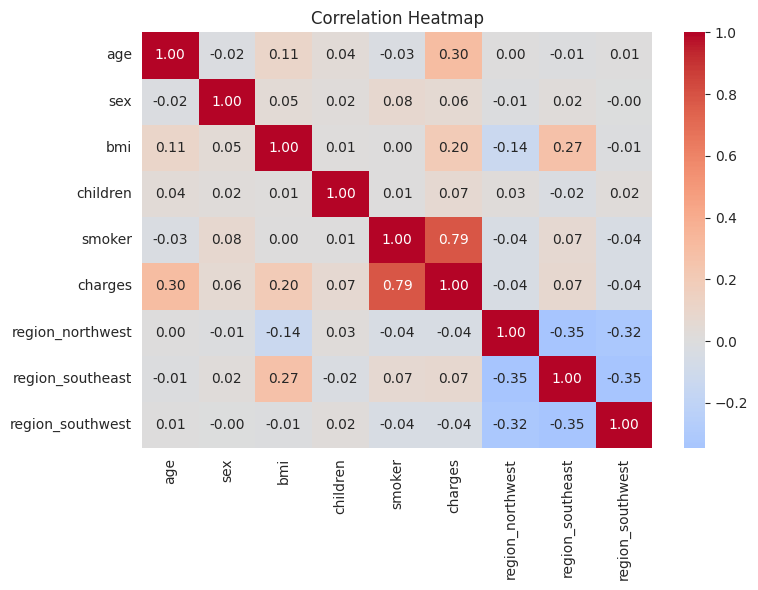

In [16]:
# 4. Correlation heatmap (numeric + encoded columns)
plt.figure(figsize=(8,6))
corr = df_encoded.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [17]:
corr['charges'].sort_values(ascending=False)


charges             1.000000
smoker              0.787234
age                 0.298308
bmi                 0.198401
region_southeast    0.073578
children            0.067389
sex                 0.058044
region_northwest   -0.038695
region_southwest   -0.043637
Name: charges, dtype: float64

**Observations:**
- `smoker` has by far the strongest correlation with `charges` — smokers pay dramatically more,
  and the gap widens further with age and BMI.
- `age` has a clear positive relationship with `charges`: costs trend upward as customers get older,
  visible as roughly three upward-sloping "bands" in the scatter plot (driven by smoking status and BMI).
- `bmi` alone has a weaker relationship with `charges`, but combined with smoking status the effect
  is much stronger — high-BMI smokers are the most expensive group by a wide margin.
- `children`, `sex`, and `region` show comparatively weak correlation with `charges`.


## Phase 5 — Train Linear Regression Model

We separate features (`X`) from the target (`y`), split into train/test sets, and train a
Multiple Linear Regression model.


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = df_encoded.drop(columns=['charges'])
y = df_encoded['charges']

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()


X shape: (1337, 8)
y shape: (1337,)


,age,sex,bmi,children,smoker,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,False,False,True
1,18,1,33.770,1,0,False,True,False
2,28,1,33.000,3,0,False,True,False
3,33,1,22.705,0,0,True,False,False
4,32,1,28.880,0,0,True,False,False


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (1069, 8)
Testing set size: (268, 8)


In [20]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Model trained successfully!")
print("\nIntercept:", model.intercept_)
coeffs = pd.Series(model.coef_, index=X.columns).sort_values(ascending=False)
coeffs


Model trained successfully!

Intercept: -11092.65229594595


smoker              23077.764593
children              533.009989
bmi                   318.701441
age                   248.210720
sex                  -101.542054
region_northwest     -391.761455
region_southwest     -659.139752
region_southeast     -838.919616
dtype: float64

In [21]:
y_pred = model.predict(X_test)

sample_results = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
}).round(2)
sample_results


,Actual,Predicted
0,8688.86,8143.69
1,5708.87,5737.12
2,11436.74,14369.31
3,38746.36,31745.51
4,4463.21,8962.39
5,9304.70,13149.72
6,38511.63,30446.76
7,2150.47,1453.29
8,7345.73,10633.02
9,10264.44,11318.94


## Phase 6 — Evaluate the Model

We compute **MAE**, **MSE**, **RMSE**, and **R² Score** to see how well the model performs, then
compare actual vs predicted charges visually.

- **MAE (Mean Absolute Error):** average absolute difference between predicted and actual charges — easy to interpret, in the same units as `charges` ($).
- **MSE (Mean Squared Error):** average of squared errors — penalizes large errors more heavily than MAE.
- **RMSE (Root Mean Squared Error):** square root of MSE — back in dollar units, but still penalizes big misses more than MAE.
- **R² Score:** proportion of the variance in `charges` explained by the model (1.0 = perfect, 0 = no better than predicting the mean).


In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R2   : {r2:.4f}")


MAE  : 4,177.05
MSE  : 35,478,020.68
RMSE : 5,956.34
R2   : 0.8069


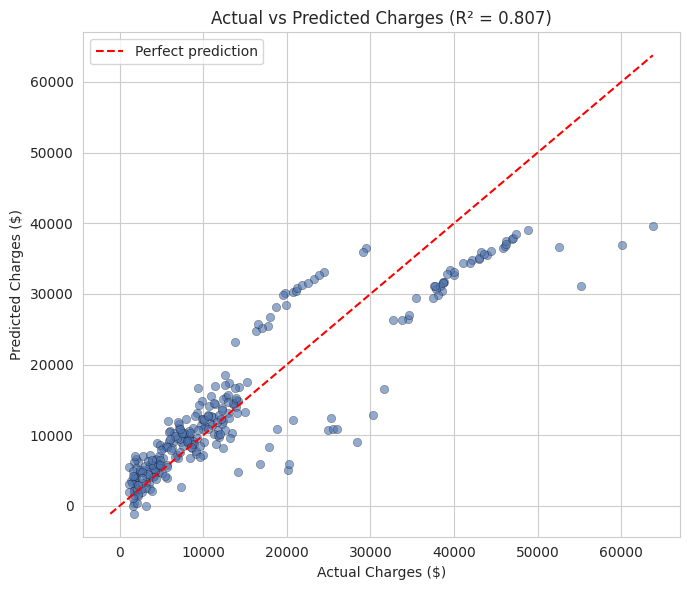

In [23]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#4C72B0', edgecolor='k', linewidth=0.3)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, 'r--', label='Perfect prediction')
plt.xlabel("Actual Charges ($)")
plt.ylabel("Predicted Charges ($)")
plt.title(f"Actual vs Predicted Charges (R² = {r2:.3f})")
plt.legend()
plt.tight_layout()
plt.show()


**Analysis:** The model captures the broad cost pattern well — it separates smokers from
non-smokers and tracks the upward trend with age — but a single straight line can't fully capture
the *interaction* between smoking status, age, and BMI (e.g. an older smoker with a high BMI costs
far more than the sum of those effects individually). This shows up as the model under- or
over-shooting for smokers in particular, which is why R² is solid but not perfect. A more advanced
model (e.g. adding interaction terms, or a tree-based model) could close this gap further — left as
a possible improvement beyond this project's scope.


## Save the Trained Model

We save the trained model and the exact column order it expects, so the Phase 7 prediction app can
load and reuse it without retraining.


In [24]:
import pickle

with open("insurance_model.pkl", "wb") as f:
    pickle.dump({
        "model": model,
        "feature_columns": list(X.columns),
        "metrics": {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}
    }, f)

print("Saved model to insurance_model.pkl")
print("Feature columns (order matters):", list(X.columns))


Saved model to insurance_model.pkl
Feature columns (order matters): ['age', 'sex', 'bmi', 'children', 'smoker', 'region_northwest', 'region_southeast', 'region_southwest']
